# HW3 Image Classification — Advanced Version
## 加入：LR Warmup / Cross Validation / TTA / Scale-up Model / Label Smoothing / Gradient Accumulation
> Kaggle 上執行

# Check GPU

In [1]:
!nvidia-smi

Sun Jul  5 14:31:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P0             28W /   70W |     107MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [17]:
import torch
print(torch.cuda.is_available())

True


# Data Path

In [18]:
import os
DATA_DIR = "/kaggle/input/competitions/ml2023spring-hw3"
print(os.listdir(DATA_DIR))

['valid', 'test', 'train']


In [21]:
_exp_name = "advanced"

# Import Packages

In [23]:
import numpy as np
import pandas as pd
import torch
import os
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import ConcatDataset, DataLoader, Subset, Dataset
from torchvision.datasets import DatasetFolder, VisionDataset
from tqdm.auto import tqdm
import random
import math

In [25]:
myseed = 6666
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(myseed)
torch.manual_seed(myseed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(myseed)

# Transforms

In [26]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# 測試 / 驗證用（固定，不隨機）
test_tfm = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# 訓練用（6 種隨機增強，Q1 要求）
train_tfm = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),       # 增強1：水平翻轉
    transforms.RandomVerticalFlip(p=0.2),          # 增強2：垂直翻轉
    transforms.RandomRotation(degrees=30),          # 增強3：旋轉
    transforms.ColorJitter(                         # 增強4：顏色抖動
        brightness=0.3, contrast=0.3,
        saturation=0.3, hue=0.1
    ),
    transforms.RandomCrop(128, padding=16),         # 增強5：隨機裁切
    transforms.RandomGrayscale(p=0.1),              # 增強6：灰階
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── TTA 用的 transform（每次呼叫都隨機，跟 train_tfm 相同）──
# TTA = Test Time Augmentation：推論時也做隨機增強，多次預測取平均
tta_tfm = train_tfm

# Dataset

In [27]:
class FoodDataset(Dataset):
    def __init__(self, path, tfm=test_tfm, files=None):
        super(FoodDataset).__init__()
        self.path = path
        self.files = sorted([
            os.path.join(path, x)
            for x in os.listdir(path)
            if x.endswith(".jpg")
        ])
        if files is not None:
            self.files = files
        self.transform = tfm

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        im = Image.open(fname)
        im = self.transform(im)
        try:
            label = int(os.path.basename(fname).split("_")[0])
        except:
            label = -1
        return im, label

# Model（Scale-up 版）

原始模型：5 個 Block，channel 最大 512

**Scale-up 改動：**
- 新增 Block 6（512 → 512），輸出 feature map 從 4×4 → 2×2
- FC 層輸入從 512×4×4=8192 改為 512×2×2=2048
- 參數量增加，表達能力更強

**mid / top layer index（t-SNE 用）：**
- mid layer = `model.cnn[:8]`（Block 1~2 後）
- top layer = `model.cnn[:19]`（全部 6 個 Block 後）

In [30]:
class Classifier(nn.Module):
    def __init__(self):
        super(Classifier, self).__init__()
        # 輸入 [B, 3, 128, 128]
        self.cnn = nn.Sequential(
            # Block 1: [B, 3, 128, 128] → [B, 64, 64, 64]
            nn.Conv2d(3, 64, 3, 1, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 2: [B, 64, 64, 64] → [B, 128, 32, 32]
            nn.Conv2d(64, 128, 3, 1, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 3: [B, 128, 32, 32] → [B, 256, 16, 16]  ← mid layer
            nn.Conv2d(128, 256, 3, 1, 1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 4: [B, 256, 16, 16] → [B, 512, 8, 8]
            nn.Conv2d(256, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 5: [B, 512, 8, 8] → [B, 512, 4, 4]
            nn.Conv2d(512, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            # Block 6（Scale-up 新增）: [B, 512, 4, 4] → [B, 512, 2, 2]  ← top layer
            # 讓模型多學一層高階語義特徵
            nn.Conv2d(512, 512, 3, 1, 1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # FC 輸入維度：512 × 2 × 2 = 2048
        self.fc = nn.Sequential(
            nn.Linear(512 * 2 * 2, 1024),
            nn.ReLU(),
            nn.Dropout(p=0.3),   # 防止過擬合
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(p=0.3),
            nn.Linear(512, 11),  # 11 類食物
        )

    def forward(self, x):
        out = self.cnn(x)
        out = out.view(out.size(0), -1)  # Flatten
        return self.fc(out)

# Configurations

In [31]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"使用裝置：{device}")

# ── Hyperparameters ──
batch_size         = 32    # Scale-up 後模型更大，降低 batch_size 避免 OOM
accumulation_steps = 4     # Gradient Accumulation：累積 4 步 = 等效 batch 128
n_epochs           = 50
patience           = 10
warmup_epochs      = 5     # LR Warmup：前 5 個 epoch 從 0 線性升到 lr_max
lr_max             = 3e-4  # Warmup 結束後的最大學習率
n_folds            = 5     # Cross Validation：5 折
tta_times          = 8     # TTA：每張圖做 8 次隨機增強，取平均

# ── Label Smoothing Cross Entropy ──
# 將標籤從 hard [0,0,1,0,...] 軟化為 [0.009,0.009,0.91,...]
# 讓模型不要對答案過度自信，提升泛化能力
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

print(f"等效 batch size：{batch_size * accumulation_steps}")
print(f"LR Warmup：前 {warmup_epochs} 個 epoch 從 0 → {lr_max:.0e}")

使用裝置：cuda
等效 batch size：128
LR Warmup：前 5 個 epoch 從 0 → 3e-04


# Learning Rate Warmup + Cosine Annealing

**Warmup 的概念：**
訓練剛開始時，模型參數是隨機初始化的，用太大的 LR 會讓參數更新過頭。
Warmup 讓 LR 從 0 慢慢升到 lr_max，等模型「暖機」後再正常訓練。

```
epoch:  0    1    2    3    4    5 ........ 50
LR:     0  6e-5 1.2e-4 1.8e-4 2.4e-4 3e-4 → Cosine 下降 → 1e-6
        |←── Warmup (5 epoch) ──→|←── Cosine Annealing ──→|
```

In [32]:
def get_lr(epoch, warmup_epochs, n_epochs, lr_max, eta_min=1e-6):
    """
    前 warmup_epochs 個 epoch：線性從 0 升到 lr_max
    之後：Cosine Annealing 從 lr_max 降到 eta_min
    """
    if epoch < warmup_epochs:
        # 線性 warmup
        return lr_max * (epoch + 1) / warmup_epochs
    else:
        # Cosine annealing
        progress = (epoch - warmup_epochs) / (n_epochs - warmup_epochs)
        return eta_min + 0.5 * (lr_max - eta_min) * (1 + math.cos(math.pi * progress))

# Cross Validation 訓練

**為什麼要 Cross Validation？**
把 train + valid 合併，重新切成 5 份，輪流用不同的份當驗證集。
每折訓練出一個模型，最後 5 個模型一起做 Ensemble 預測。

```
fold 1：[valid] [train] [train] [train] [train] → model_fold1.ckpt
fold 2：[train] [valid] [train] [train] [train] → model_fold2.ckpt
fold 3：[train] [train] [valid] [train] [train] → model_fold3.ckpt
fold 4：[train] [train] [train] [valid] [train] → model_fold4.ckpt
fold 5：[train] [train] [train] [train] [valid] → model_fold5.ckpt

最終預測 = 5 個模型輸出的平均
```

In [33]:
# ── 載入所有資料（train + valid 合併，用來做 CV）──
all_train_files = (
    sorted([os.path.join(DATA_DIR, "train", x)
            for x in os.listdir(os.path.join(DATA_DIR, "train"))
            if x.endswith(".jpg")])
  + sorted([os.path.join(DATA_DIR, "valid", x)
            for x in os.listdir(os.path.join(DATA_DIR, "valid"))
            if x.endswith(".jpg")])
)
print(f"合併後總筆數：{len(all_train_files)}")

# ── 切成 n_folds 折 ──
fold_size   = len(all_train_files) // n_folds
fold_indices = []
for k in range(n_folds):
    start = k * fold_size
    end   = start + fold_size if k < n_folds - 1 else len(all_train_files)
    fold_indices.append(list(range(start, end)))

print(f"每折大小約：{fold_size} 筆")

合併後總筆數：13643
每折大小約：2728 筆


# Training Function（單折）

In [36]:
def train_one_fold(fold_k, train_files, valid_files, resume_ckpt=None):
    """
    訓練單一折，回傳該折最佳 valid accuracy。
    模型存到 {_exp_name}_fold{fold_k}.ckpt
    resume_ckpt: 若不為 None，從中斷點繼續訓練
    """
    print(f"\n{'='*50}")
    print(f"Fold {fold_k+1}/{n_folds}  訓練:{len(train_files)}  驗證:{len(valid_files)}")
    print(f"{'='*50}")

    # Dataset & DataLoader
    train_set = FoodDataset(DATA_DIR+"/train", tfm=train_tfm, files=train_files)
    valid_set = FoodDataset(DATA_DIR+"/train", tfm=test_tfm,  files=valid_files)
    train_loader = DataLoader(train_set, batch_size=batch_size,
                              shuffle=True,  num_workers=2, persistent_workers=True, pin_memory=True)
    valid_loader = DataLoader(valid_set, batch_size=batch_size,
                              shuffle=False, num_workers=2, persistent_workers=True, pin_memory=True)

    # 每折都重新初始化模型和 optimizer
    model     = nn.DataParallel(Classifier()).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr_max, weight_decay=1e-5)

    # ── 預設從頭開始 ──
    start_epoch = 0
    best_acc    = 0
    stale       = 0

    # ── 若有中斷點，載入狀態繼續 ──
    if resume_ckpt is not None:
        model.module.load_state_dict(resume_ckpt["model"])
        optimizer.load_state_dict(resume_ckpt["optimizer"])
        start_epoch = resume_ckpt["epoch"] + 1  # 從下一個 epoch 繼續
        best_acc    = resume_ckpt["best_acc"]
        stale       = resume_ckpt["stale"]
        print(f"從 epoch {start_epoch+1} 繼續，目前最佳 acc = {best_acc:.5f}")

    for epoch in range(start_epoch, n_epochs):
        # ── 計算並更新學習率（Warmup + Cosine）──
        lr = get_lr(epoch, warmup_epochs, n_epochs, lr_max)
        for param_group in optimizer.param_groups:
            param_group["lr"] = lr

        # ────────── Training ──────────
        model.train()
        train_loss, train_accs = [], []

        optimizer.zero_grad()  # Gradient Accumulation：在 epoch 開始前清零

        for i, (imgs, labels) in enumerate(tqdm(train_loader, desc=f"Fold{fold_k+1} Epoch{epoch+1} Train")):
            logits = model(imgs.to(device))
            loss   = criterion(logits, labels.to(device))

            # Gradient Accumulation：loss 除以累積步數，避免梯度被放大
            loss = loss / accumulation_steps
            loss.backward()

            # 累積夠 accumulation_steps 步才更新一次
            if (i + 1) % accumulation_steps == 0 or (i + 1) == len(train_loader):
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=10)
                optimizer.step()
                optimizer.zero_grad()

            acc = (logits.argmax(dim=-1) == labels.to(device)).float().mean()
            train_loss.append(loss.item() * accumulation_steps)
            train_accs.append(acc)

        train_loss = sum(train_loss) / len(train_loss)
        train_acc  = sum(train_accs) / len(train_accs)
        print(f"[ Train | {epoch+1:03d}/{n_epochs:03d} ] loss={train_loss:.4f} acc={train_acc:.4f} lr={lr:.2e}")

        # ────────── Validation ──────────
        model.eval()
        valid_loss, valid_accs = [], []

        for imgs, labels in tqdm(valid_loader, desc=f"Fold{fold_k+1} Epoch{epoch+1} Valid"):
            with torch.no_grad():
                logits = model(imgs.to(device))
            loss = criterion(logits, labels.to(device))
            acc  = (logits.argmax(dim=-1) == labels.to(device)).float().mean()
            valid_loss.append(loss.item())
            valid_accs.append(acc)

        valid_loss = sum(valid_loss) / len(valid_loss)
        valid_acc  = sum(valid_accs) / len(valid_accs)
        print(f"[ Valid | {epoch+1:03d}/{n_epochs:03d} ] loss={valid_loss:.4f} acc={valid_acc:.4f}")

        # Log
        with open(f"{_exp_name}_fold{fold_k}_log.txt", "a") as f:
            msg = f"[{epoch+1:03d}] loss={valid_loss:.4f} acc={valid_acc:.4f}"
            print(msg + (" -> best" if valid_acc > best_acc else ""), file=f)

        # 儲存最佳模型 & Early Stopping
        if valid_acc > best_acc:
            print(f"  ✓ Best model at epoch {epoch+1}, saving...")
            torch.save(model.module.state_dict(), f"{_exp_name}_fold{fold_k}.ckpt")
            best_acc = valid_acc
            stale = 0
        else:
            stale += 1
            if stale > patience:
                print(f"  Early stopping at epoch {epoch+1}")
                # early stop 前也存一次 checkpoint
                torch.save({
                    "fold":      fold_k,
                    "epoch":     epoch,
                    "model":     model.module.state_dict(),
                    "optimizer": optimizer.state_dict(),
                    "best_acc":  best_acc,
                    "stale":     stale,
                }, f"{_exp_name}_fold{fold_k}_checkpoint.pt")
                break

        # ── 每個 epoch 結束存完整 checkpoint（斷線可從這裡繼續）──
        torch.save({
            "fold":      fold_k,
            "epoch":     epoch,
            "model":     model.module.state_dict(),
            "optimizer": optimizer.state_dict(),
            "best_acc":  best_acc,
            "stale":     stale,
        }, f"{_exp_name}_fold{fold_k}_checkpoint.pt")

    print(f"Fold {fold_k+1} 完成！最佳 valid acc = {best_acc:.5f}")
    return best_acc

# Run Cross Validation

In [37]:
# ── 執行 5 折 Cross Validation ──
fold_accs = []

for k in range(n_folds):
    # 這一折的驗證 index
    valid_idx = fold_indices[k]
    # 其他折的 index 合併成訓練集
    train_idx = []
    for j in range(n_folds):
        if j != k:
            train_idx.extend(fold_indices[j])
    train_files = [all_train_files[i] for i in train_idx]
    valid_files = [all_train_files[i] for i in valid_idx]

    # ── 這折已完成，跳過 ──
    ckpt_path       = f"{_exp_name}_fold{k}.ckpt"
    resume_ckpt_path = f"{_exp_name}_fold{k}_checkpoint.pt"

    if os.path.exists(ckpt_path) and not os.path.exists(resume_ckpt_path):
        print(f"Fold {k+1} 已完成，跳過")
        # 讀取 log 取得該折 best_acc
        fold_accs.append(None)
        continue

    # ── 這折跑一半斷掉，從中間繼續 ──
    resume_ckpt = None
    if os.path.exists(resume_ckpt_path):
        print(f"Fold {k+1} 偵測到中斷點，從中繼續...")
        resume_ckpt = torch.load(resume_ckpt_path)

    acc = train_one_fold(k, train_files, valid_files, resume_ckpt)
    fold_accs.append(acc)

    # 訓練完成後刪除 checkpoint，避免下次誤判為未完成
    if os.path.exists(resume_ckpt_path):
        os.remove(resume_ckpt_path)
        print(f"Fold {k+1} checkpoint 已清除")

print(f"\n{'='*50}")
print(f"Cross Validation 結果：")
for k, acc in enumerate(fold_accs):
    if acc is not None:
        print(f"  Fold {k+1}: {acc:.5f}")
    else:
        print(f"  Fold {k+1}: 已跳過（從 ckpt 載入）")

# 過濾掉 None 再算平均
valid_accs = [a for a in fold_accs if a is not None]
if valid_accs:
    print(f"  平均 valid acc: {sum(valid_accs)/len(valid_accs):.5f}")

Fold 1 已完成，跳過
Fold 2 已完成，跳過
Fold 3 已完成，跳過
Fold 4 已完成，跳過
Fold 5 已完成，跳過

Cross Validation 結果：
  Fold 1: 已跳過（從 ckpt 載入）
  Fold 2: 已跳過（從 ckpt 載入）
  Fold 3: 已跳過（從 ckpt 載入）
  Fold 4: 已跳過（從 ckpt 載入）
  Fold 5: 已跳過（從 ckpt 載入）


# Testing with TTA（Test Time Augmentation）

**TTA 的流程：**
同一張圖用 `train_tfm`（隨機增強）處理 N 次，
每次預測一次，最後對 N 次的輸出機率取平均再選類別。

```
原圖 ─→ 增強版本1 ─→ 模型 ─→ [0.1, 0.6, 0.3, ...]
     ─→ 增強版本2 ─→ 模型 ─→ [0.2, 0.5, 0.3, ...]   → 平均 → argmax → 類別
     ─→ 增強版本3 ─→ 模型 ─→ [0.1, 0.7, 0.2, ...]
     ...（共 tta_times 次）
```

**Ensemble + TTA：** 把所有折的模型都跑一遍 TTA，最後對全部結果取平均。

In [42]:
# ── 載入測試集 ──
test_set    = FoodDataset(f"{DATA_DIR}/test", tfm=test_tfm)
test_loader_normal = DataLoader(test_set, batch_size=batch_size,
                                shuffle=False, num_workers=2, persistent_workers=True, pin_memory=True)

# TTA 用的 dataset（每次讀都用 train_tfm 隨機增強）
class TTADataset(Dataset):
    """包裝 FoodDataset，強制使用 train_tfm，每次讀取結果都不同"""
    def __init__(self, base_dataset, tta_tfm):
        self.base    = base_dataset
        self.tta_tfm = tta_tfm
        # 把原始 PIL Image 存起來（不做 transform）
        self.pil_imgs = []
        for f in base_dataset.files:
            self.pil_imgs.append(Image.open(f).convert("RGB"))

    def __len__(self):
        return len(self.pil_imgs)

    def __getitem__(self, idx):
        return self.tta_tfm(self.pil_imgs[idx]), -1  # label=-1（test 沒標籤）

tta_dataset = TTADataset(test_set, tta_tfm)
tta_loader  = DataLoader(tta_dataset, batch_size=batch_size,
                         shuffle=False, num_workers=0, pin_memory=True)

print(f"測試集大小：{len(test_set)}")
print(f"TTA 次數：{tta_times}（每張圖做 {tta_times} 次隨機增強）")
print(f"參與 Ensemble 的模型數：{n_folds} 折")

測試集大小：3000
TTA 次數：8（每張圖做 8 次隨機增強）
參與 Ensemble 的模型數：5 折


In [44]:
# ── Ensemble + TTA 預測 ──
# all_logits shape: (len(test_set), 11)
# 累加所有模型、所有 TTA 次數的 logits，最後取 argmax

all_logits = torch.zeros(len(test_set), 11)  # 累加用

for k in range(n_folds):
    ckpt_path = f"{_exp_name}_fold{k}.ckpt"
    if not os.path.exists(ckpt_path):
        print(f"找不到 {ckpt_path}，跳過")
        continue

    model_k = nn.DataParallel(Classifier()).to(device)
    model_k.module.load_state_dict(torch.load(ckpt_path))
    model_k.eval()
    print(f"\nFold {k+1} 模型載入完成")

    # 1. 一般預測（不做增強）
    print(f"  Fold {k+1} 一般預測...")
    with torch.no_grad():
        for i, (imgs, _) in enumerate(tqdm(test_loader_normal)):
            logits = model_k(imgs.to(device)).cpu()
            start  = i * batch_size
            end    = start + logits.size(0)
            all_logits[start:end] += logits

    # 2. TTA 預測（tta_times 次隨機增強）
    for t in range(tta_times):
        print(f"  Fold {k+1} TTA {t+1}/{tta_times}...")
        # 每次重新建立 DataLoader，確保 TTADataset 重新隨機增強
        tta_loader_t = DataLoader(
            tta_dataset, batch_size=batch_size,
            shuffle=False, num_workers=0, pin_memory=True
    )
    with torch.no_grad():
        for i, (imgs, _) in enumerate(tqdm(tta_loader_t)):
            logits = model_k(imgs.to(device)).cpu()
            start  = i * batch_size
            end    = start + logits.size(0)
            all_logits[start:end] += logits

# 所有模型 + TTA 的 logits 取平均後 argmax
prediction = all_logits.argmax(dim=1).numpy().tolist()
print(f"\n預測完成！共 {len(prediction)} 筆")


Fold 1 模型載入完成
  Fold 1 一般預測...


  0%|          | 0/94 [00:00<?, ?it/s]

  Fold 1 TTA 1/8...
  Fold 1 TTA 2/8...
  Fold 1 TTA 3/8...
  Fold 1 TTA 4/8...
  Fold 1 TTA 5/8...
  Fold 1 TTA 6/8...
  Fold 1 TTA 7/8...
  Fold 1 TTA 8/8...


  0%|          | 0/94 [00:00<?, ?it/s]


Fold 2 模型載入完成
  Fold 2 一般預測...


...


Fold 5 模型載入完成
  Fold 5 一般預測...


  0%|          | 0/94 [00:00<?, ?it/s]

  Fold 5 TTA 1/8...
  Fold 5 TTA 2/8...
  Fold 5 TTA 3/8...
  Fold 5 TTA 4/8...
  Fold 5 TTA 5/8...
  Fold 5 TTA 6/8...
  Fold 5 TTA 7/8...
  Fold 5 TTA 8/8...


  0%|          | 0/94 [00:00<?, ?it/s]


預測完成！共 3000 筆


# Generate submission.csv

In [45]:
def pad4(i):
    return str(i).zfill(4)

df = pd.DataFrame()
df["Id"]       = [pad4(i) for i in range(len(test_set))]
df["Category"] = prediction
df.to_csv("submission.csv", index=False)
print("submission.csv 已儲存！")
print(df.head(10))

from IPython.display import FileLink
FileLink('submission.csv')

submission.csv 已儲存！
     Id  Category
0  0000         5
1  0001         1
2  0002         0
3  0003         3
4  0004         9
5  0005        10
6  0006         3
7  0007         3
8  0008         1
9  0009         3


/kaggle/working/submission.csv

# Q1. Augmentation Implementation

In [46]:
train_tfm = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomCrop(128, padding=16),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Q2. t-SNE 視覺化

用 Fold 0 的模型做視覺化。

**Scale-up 模型的 layer index：**
- mid layer = `model.cnn[:8]`（Block 1~2 後，低階紋理）
- top layer = `model.cnn[:19]`（全部 6 個 Block 後，高階語義）

In [49]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# 載入 Fold 0 的模型
model_vis = nn.DataParallel(Classifier()).to(device)
model_vis.module.load_state_dict(torch.load(f"{_exp_name}_fold0.ckpt"))
model_vis.eval()

# 確認 layer index
print("CNN sub-layers:")
for i, layer in enumerate(model_vis.module.cnn):
    print(f"  [{i}] {layer}")

CNN sub-layers:
  [0] Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [1] BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  [2] ReLU()
  [3] MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  [4] Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [5] BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  [6] ReLU()
  [7] MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  [8] Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [9] BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  [10] ReLU()
  [11] MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  [12] Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  [13] BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  [14] ReLU()
  [15] MaxPool2d(kernel_size=2, stride=2, pad

Extracting [Mid Layer (Block 1-2)]:   0%|          | 0/57 [00:00<?, ?it/s]

[Mid Layer (Block 1-2)] feature 維度：(3643, 131072)
[Mid Layer (Block 1-2)] 執行 t-SNE 中（可能需要數分鐘）...


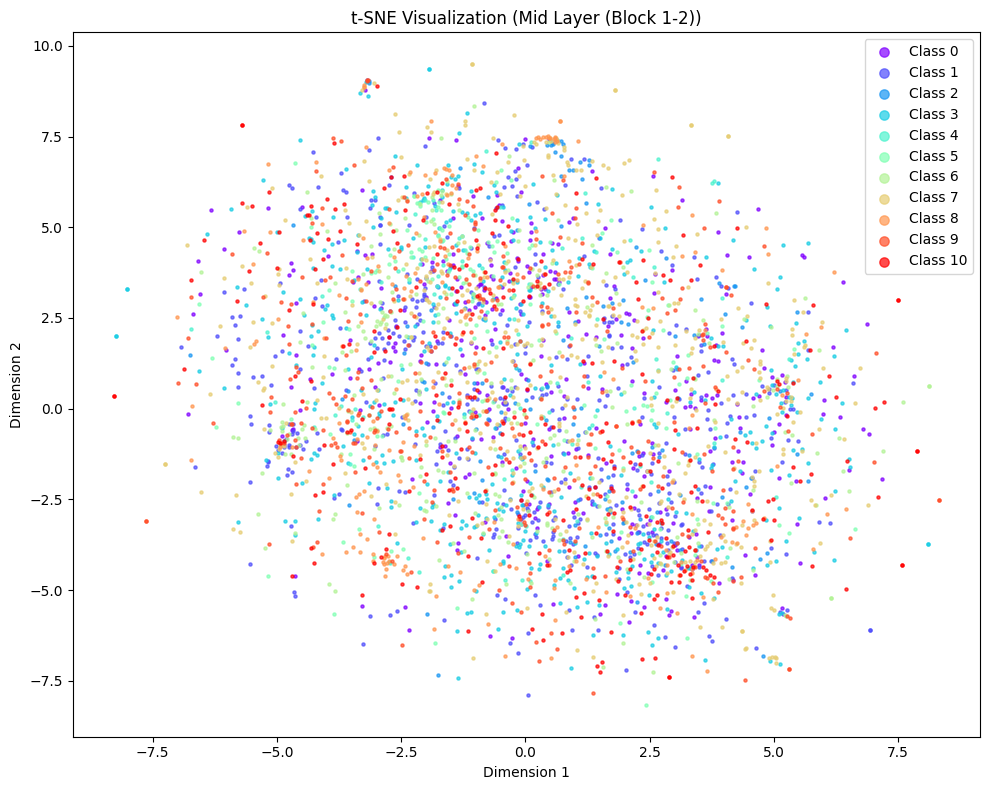

圖片已儲存：tsne_Mid_Layer_(Block_1-2).png


Extracting [Top Layer (Block 1-6)]:   0%|          | 0/57 [00:00<?, ?it/s]

[Top Layer (Block 1-6)] feature 維度：(3643, 32768)
[Top Layer (Block 1-6)] 執行 t-SNE 中（可能需要數分鐘）...


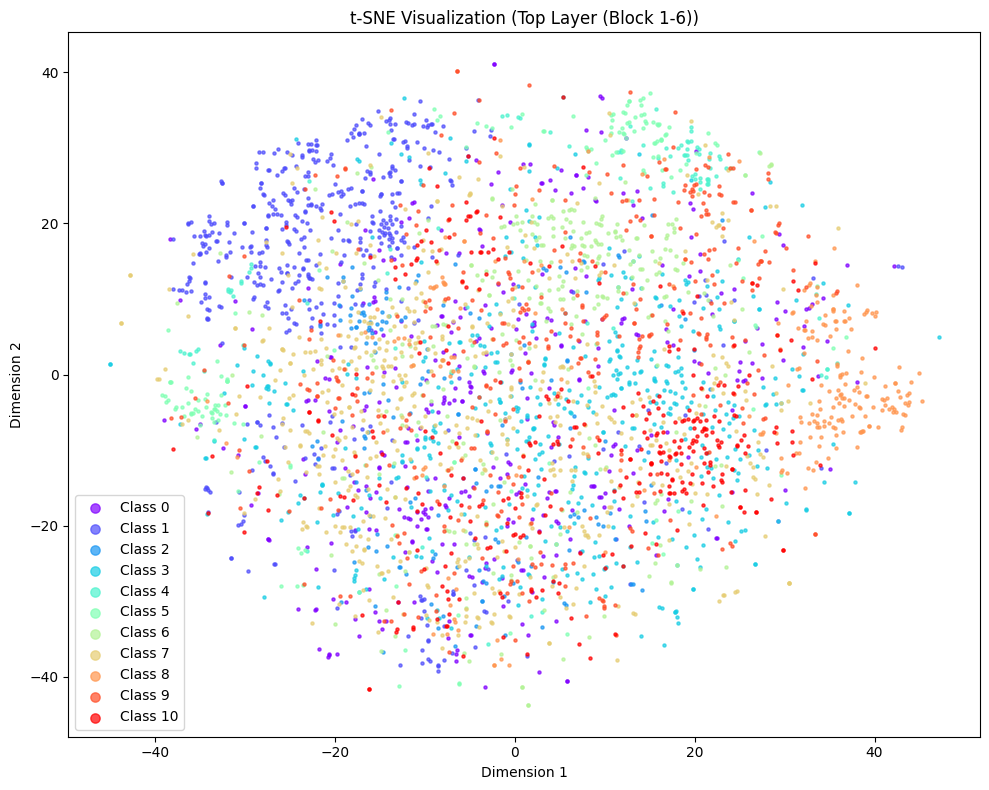

圖片已儲存：tsne_Top_Layer_(Block_1-6).png


In [51]:
# 用原本 valid set 做 t-SNE（TA 指定的 valid 資料）
vis_valid_set    = FoodDataset(f"{DATA_DIR}/valid", tfm=test_tfm)
vis_valid_loader = DataLoader(vis_valid_set, batch_size=64,
                               shuffle=False, num_workers=2, persistent_workers=True, pin_memory=True)

def visualize_tsne(model, loader, layer_index, title, device):
    features_list, labels_list = [], []
    for imgs, lbls in tqdm(loader, desc=f"Extracting [{title}]"):
        with torch.no_grad():
            feat = model.module.cnn[:layer_index](imgs.to(device))  
            feat = feat.view(feat.size(0), -1)
        features_list.extend(feat.cpu().numpy())
        labels_list.extend(lbls.numpy())

    features = np.array(features_list)
    labels   = np.array(labels_list)
    print(f"[{title}] feature 維度：{features.shape}")
    print(f"[{title}] 執行 t-SNE 中（可能需要數分鐘）...")

    features_2d = TSNE(n_components=2, init='pca',
                       random_state=42, perplexity=30).fit_transform(features)

    plt.figure(figsize=(10, 8))
    colors = cm.rainbow(np.linspace(0, 1, 11))
    for label_id in np.unique(labels):
        mask = (labels == label_id)
        plt.scatter(features_2d[mask, 0], features_2d[mask, 1],
                    label=f"Class {label_id}", color=colors[label_id],
                    s=5, alpha=0.7)
    plt.legend(markerscale=3, loc='best')
    plt.title(f"t-SNE Visualization ({title})")
    plt.xlabel("Dimension 1")
    plt.ylabel("Dimension 2")
    plt.tight_layout()
    fname = f"tsne_{title.replace(' ', '_')}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"圖片已儲存：{fname}")

# mid layer（Block 1~2 後，index=8）
visualize_tsne(model_vis, vis_valid_loader, layer_index=8,
               title="Mid Layer (Block 1-2)", device=device)

# top layer（全部 6 個 Block 後，index=19）
visualize_tsne(model_vis, vis_valid_loader, layer_index=19,
               title="Top Layer (Block 1-6)", device=device)